# Multivariate Analysis
### Analyzing Complex Interactions Across Three or More Variables Simultaneously

---

### Scope & Focus of This Notebook
- **Primary Topic**: Multivariate Exploratory Data Analysis — exploring 3 or more variables simultaneously to uncover interactions and confounding factors.
- **What You Will Learn**:
  1. Multi-channel visual encodings: Combining horizontal position (`x`), vertical position (`y`), color (`hue`), marker symbol (`style`), and point diameter (`size`) in `sns.scatterplot`.
  2. Multivariate pair plots: Adding categorical hue stratification to pairwise grids.
  3. Faceted category grids: Multi-panel categorization using `sns.catplot`.
  4. Faceted distribution grids: Conditional density slicing using `sns.FacetGrid`.
  5. Multi-variable pivot tables: Computing 3-way interactions with `df.pivot_table()` and visualizing with annotated heatmaps.
  6. Confounder discovery: How traveling class, gender, and age jointly determined survival on the Titanic.
- **What We Will NOT Cover Here**:
  - Single-variable distributions are covered in **`01_Univariate_Analysis`**.
  - Simple 2-variable relationships belong to **`02_Bivariate_Analysis`**.
  - Automated profiling reports are in **`04_Pandas_Profiling`**.
  - Dimensionality reduction (PCA) and feature transformations belong to subsequent modules.

---

## 1. Setup & Load Dataset

### What are we doing?
We import data science libraries (`pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`) and load the Titanic dataset using robust relative path checking.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Robust path resolution
data_path = '../../data/titanic.csv' if os.path.exists('../../data/titanic.csv') else 'data/titanic.csv'
df = pd.read_csv(data_path)

print(f"Loaded Titanic dataset: {df.shape[0]} rows, {df.shape[1]} columns")


Loaded Titanic dataset: 891 rows, 12 columns


## 2. Multi-Channel Visual Encodings on a Scatter Plot

### What are we doing?
We encode 5 different variables into a single 2D scatter plot:
1. **$x$-axis**: `Age` (continuous numerical)
2. **$y$-axis**: `Fare` (continuous numerical)
3. **Color (`hue`)**: `Survived` (binary target: red = perished, green = survived)
4. **Point Size (`size`)**: `Pclass` (ordinal category: larger points = 1st class)
5. **Marker Style (`style`)**: `Sex` (nominal category: circles = female, squares = male)

#### What does `sns.scatterplot()` do here?
Maps distinct dimensions of each data sample to separate graphical properties.

#### Why are we doing this?
To immediately identify multi-dimensional clusters and interaction patterns without training complex models.

#### What is the implication?
Green circles (surviving females) and large markers (1st class) are concentrated in high fare regions, while red squares (perished males) dominate lower fare and younger/middle-age regions.


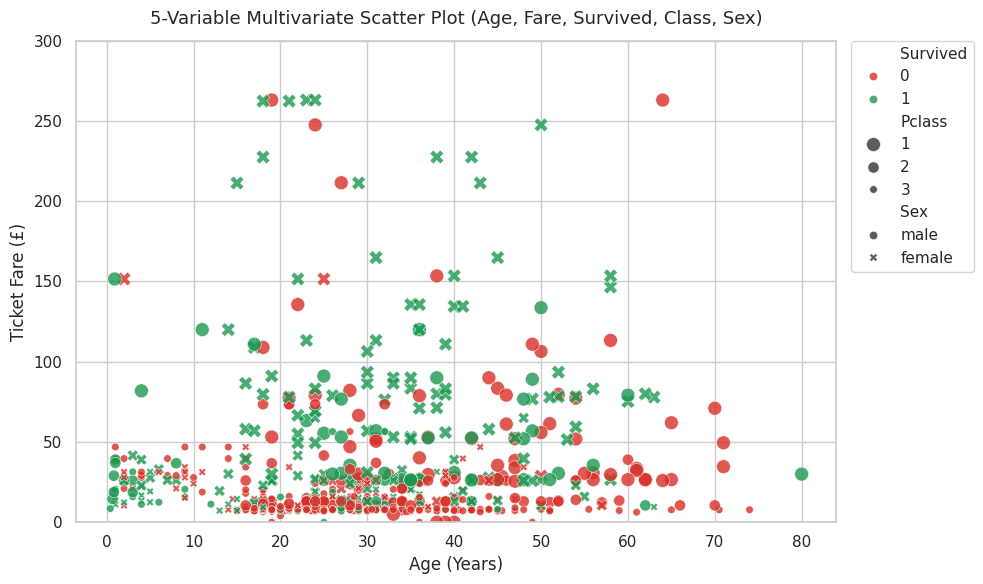

In [2]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='Age', 
    y='Fare', 
    hue='Survived', 
    size='Pclass', 
    sizes=(100, 30), 
    style='Sex', 
    palette={0: '#d73027', 1: '#1a9850'}, 
    alpha=0.8
)

plt.title('5-Variable Multivariate Scatter Plot (Age, Fare, Survived, Class, Sex)', fontsize=13, pad=12)
plt.xlabel('Age (Years)')
plt.ylabel('Ticket Fare (£)')
plt.ylim(0, 300)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()

# Save plot robustly
plot_dir = '../../outputs/plots' if os.path.exists('../../outputs/plots') else ('outputs/plots' if os.path.exists('outputs/plots') else '.')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, 'multivariate_scatter_5_vars.png'), dpi=150)
plt.show()


## 3. Multivariate Pair Plot with Hue Conditioning

### What are we doing?
We generate a pairwise feature grid stratified by survival outcome (`hue='Survived'`).

#### What does `sns.pairplot(data, hue='...')` do?
Draws pairwise scatter plots for all numerical features while coloring points by a categorical target and plotting class-conditional KDE densities along the diagonal.

#### What is the implication?
The diagonal density curves immediately highlight where survivor distributions separate from perished distributions (e.g. higher survival density at higher `Fare` and young `Age`).


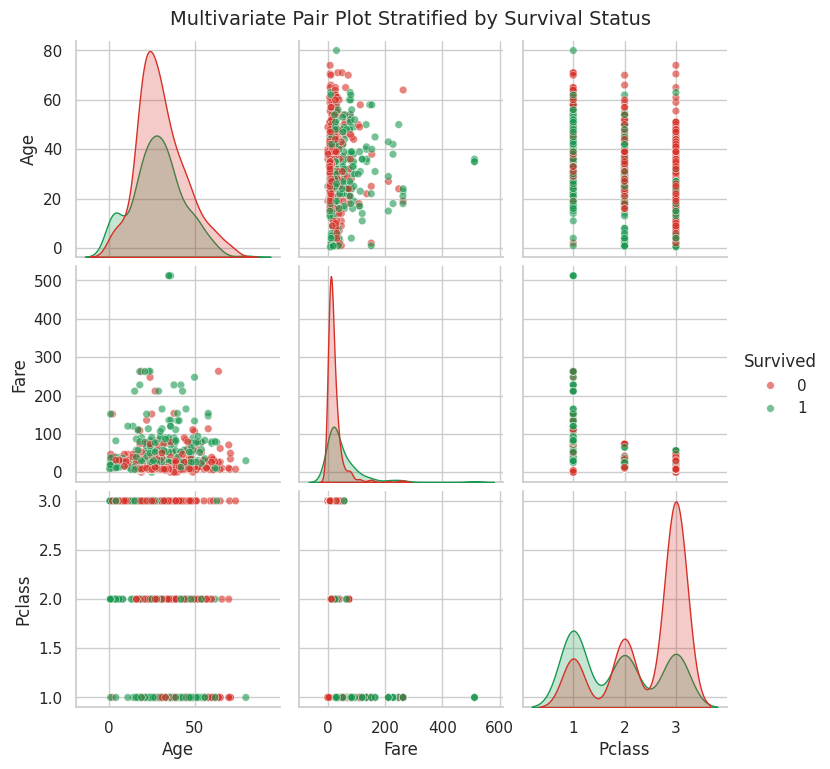

In [3]:
multivariate_cols = ['Age', 'Fare', 'Pclass', 'Survived']
clean_subset = df[multivariate_cols].dropna()

g = sns.pairplot(
    clean_subset, 
    hue='Survived', 
    palette={0: '#d73027', 1: '#1a9850'}, 
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)
g.fig.suptitle('Multivariate Pair Plot Stratified by Survival Status', y=1.02, fontsize=14)
plt.show()


## 4. Faceted Categorical Analysis (`sns.catplot`)

### What are we doing?
We create a 3-way faceted category plot: Survival rates across `Sex` (x-axis), separated into columns by `Pclass` (1st, 2nd, 3rd class).

#### What does `sns.catplot()` do?
Constructs a multi-panel categorical figure by splitting data across distinct facet columns or rows based on conditioning variables.

#### Why are we doing this?
It avoids visual clutter by giving each passenger class its own clean subplot.

#### What is the implication?
- 1st & 2nd Class Females: $> 90\%$ survived.
- 3rd Class Females: Survival dropped to ~50%.
- 1st Class Males: Survival was ~37%.
- 2nd & 3rd Class Males: Survival dropped below 16%.
Reveals that while gender was the primary driver, social class heavily gated survival chances.


/var/folders/z8/bjhnq05d3ygdk3mnkcvm6ys80000gn/T/ipykernel_7547/1415482596.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


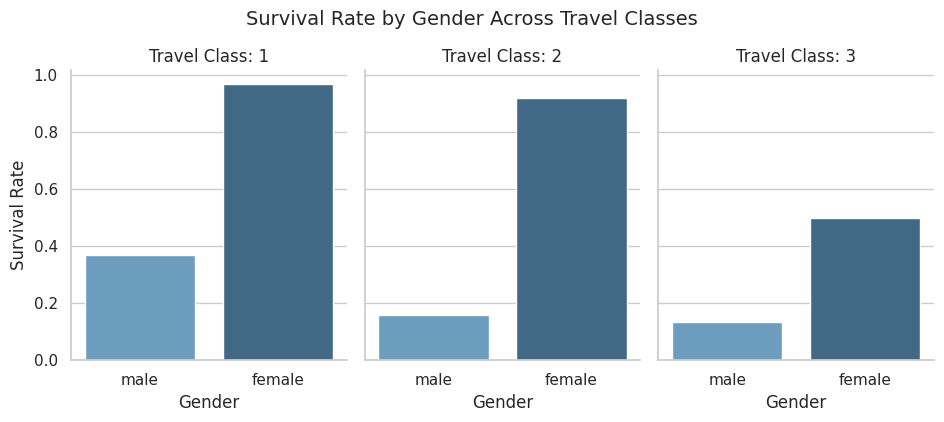

In [4]:
g = sns.catplot(
    data=df, 
    x='Sex', 
    y='Survived', 
    col='Pclass', 
    kind='bar', 
    palette='Blues_d', 
    height=4, 
    aspect=0.8,
    errorbar=None
)

g.set_axis_labels("Gender", "Survival Rate")
g.set_titles(col_template="Travel Class: {col_name}")
g.fig.suptitle('Survival Rate by Gender Across Travel Classes', y=1.05, fontsize=14)
plt.show()


### 4.1 Faceted Continuous Density Grid (`sns.FacetGrid`)

### What are we doing?
We plot the continuous `Age` distribution conditioned on `Survived` (columns) across `Pclass` (rows).

#### What does `sns.FacetGrid()` do?
Creates a matrix of subplots mapped to categorical subsets, allowing any plotting function (like `sns.kdeplot`) to be mapped across every panel via `g.map()`.


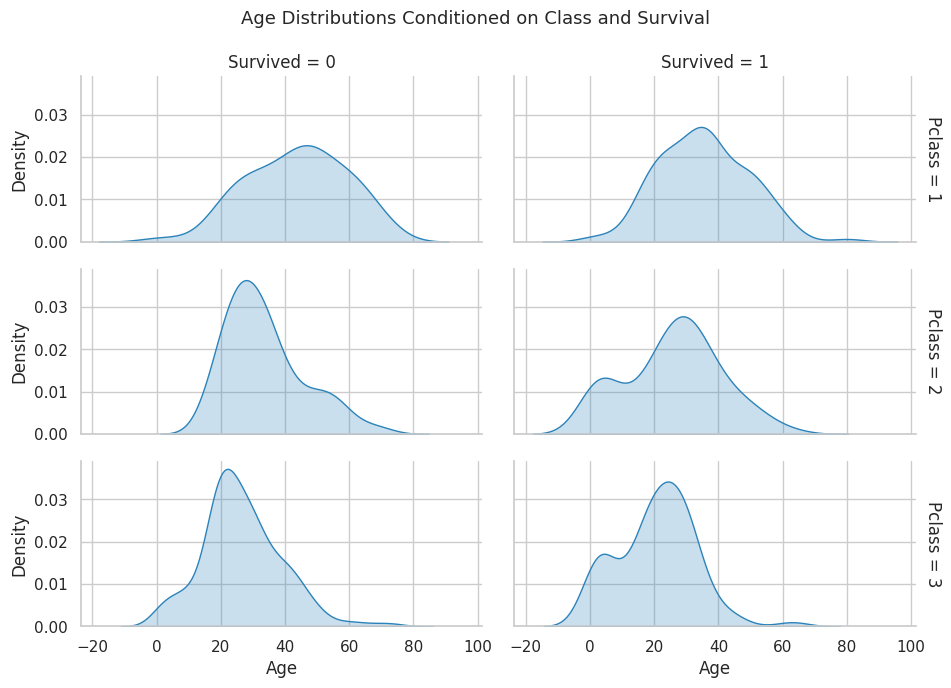

In [5]:
g = sns.FacetGrid(df, row='Pclass', col='Survived', height=2.2, aspect=2.2, margin_titles=True)
g.map(sns.kdeplot, 'Age', fill=True, color='#2b83ba')
g.fig.suptitle('Age Distributions Conditioned on Class and Survival', y=1.04, fontsize=13)
plt.show()


## 5. Multi-Variable Aggregation: Pivot Tables & Heatmaps

### What are we doing?
We aggregate survival rates across 3 features simultaneously: `Pclass` along rows, `Sex` along columns, and mean `Survived` as the aggregated cell values.

#### What does `df.pivot_table()` do?
Reshapes tabular data by aggregating values along index rows and column headers using a summary function (default `mean`).

#### What is the implication?
Produces a clean 2D summary matrix of 3-way interactions that can be rendered directly as an annotated heatmap.


--- 3-Way Survival Rate (%) Matrix ---


Sex,female,male
Pclass,,
1,96.8,36.9
2,92.1,15.7
3,50.0,13.5


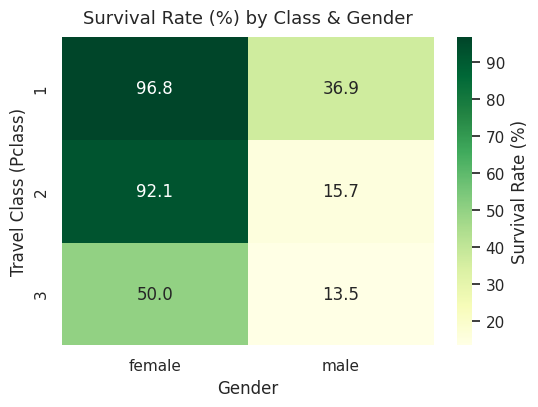

In [6]:
# 3-Way Pivot Table: Survival Rate (%) by Class and Sex
pivot_survival = (df.pivot_table(
    index='Pclass', 
    columns='Sex', 
    values='Survived', 
    aggfunc='mean'
) * 100).round(1)

print("--- 3-Way Survival Rate (%) Matrix ---")
display(pivot_survival)

# Heatmap visualization
plt.figure(figsize=(6, 4))
sns.heatmap(pivot_survival, annot=True, fmt='.1f', cmap='YlGn', cbar_kws={'label': 'Survival Rate (%)'})
plt.title('Survival Rate (%) by Class & Gender', fontsize=13, pad=10)
plt.xlabel('Gender')
plt.ylabel('Travel Class (Pclass)')

# Save plot
plt.savefig(os.path.join(plot_dir, 'multivariate_pivot_heatmap.png'), dpi=150)
plt.show()


---

## What We Learned
- **Visual Encoding Channels**: Position, color (`hue`), symbol (`style`), and size (`size`) allow up to 5 dimensions to be analyzed in a single chart.
- **Multivariate Pair Plots**: Adding `hue` to pair plot grids displays multivariate class separation across feature pairs.
- **Faceted Grids**: `sns.catplot` and `sns.FacetGrid` deconstruct complex multi-dimensional interactions into organized, uncluttered subplots.
- **Pivot Table Heatmaps**: `df.pivot_table()` quantifies 3-way interactions in a compact numerical format easily visualizable via heatmaps.
- **Interaction Effects**: Proved that Titanic survival was not determined by gender alone, nor class alone, but by their specific combination.

---

## Important Takeaways
1. **Never rely on bivariate analysis alone when confounders exist**: Analyzing `Sex` vs `Survived` shows women had high survival; multivariate analysis shows 3rd class women had roughly half the survival rate of 1st class women.
2. **Limit channels on single scatter plots to avoid visual overload**: Combining more than 4-5 visual channels confuses human readers. Use faceting (`catplot` / `FacetGrid`) instead of overloading one axis.
3. **Use Pivot Tables for executive summaries**: A 2D pivot table summarizing 3 features is often much easier to interpret than a complex 3D plot.

---

## Common Mistakes
1. **Over-encoding a single plot**: Using 6 different marker symbols with 8 colors and variable sizes makes a plot unreadable.
2. **Ignoring Simpson's Paradox**: A trend appearing across combined data can reverse when stratified into subgroups. Multivariate analysis is the primary tool to catch this.
3. **Treating continuous variables as facet panels**: Faceting on continuous features produces hundreds of empty subplots. Always discretize continuous features before faceting.

---

## Final Mental Model

```text
┌────────────────────────────────────────────────────────────────────────┐
│                     MULTIVARIATE ANALYSIS STRATEGY                     │
└────────────────────────────────────────────────────────────────────────┘
          │
          ├──► Multi-Channel 2D  ──► x, y, hue, style, size in sns.scatterplot()
          │
          ├──► Faceted Grids     ──► sns.catplot()   : Categorical subpanels
          │                      ──► sns.FacetGrid() : Continuous density subpanels
          │
          └──► Aggregated Matrix ──► df.pivot_table(index, cols, values, mean)
                                 ──► sns.heatmap()
```
